In [1]:
import numpy as np
import healpy as hp
#from rubin_scheduler.scheduler.utils import make_rolling_footprints
DEFAULT_NSIDE = 32
from rubin_scheduler.scheduler.utils import Footprint, Footprints, CurrentAreaMap, StepSlopes, slice_quad_galactic_cut
import copy

from rubin_scheduler.scheduler.utils import CurrentAreaMap, Footprint
from rubin_scheduler.scheduler.model_observatory import ModelObservatory

import healpy as hp
%matplotlib inline
import numpy as np

import rubin_scheduler.scheduler.basis_functions as bf
from rubin_scheduler.scheduler.surveys import BlobSurvey
from rubin_scheduler.scheduler.schedulers import CoreScheduler, BaseQueueManager
from rubin_scheduler.scheduler import sim_runner
from rubin_scheduler.utils import DEFAULT_NSIDE, ra_dec2_hpid

from rubin_scheduler.scheduler.basis_functions import BaseBasisFunction
from rubin_scheduler.scheduler.detailers import BaseDetailer
from rubin_scheduler.site_models import Almanac


import matplotlib.pylab as plt
from astropy.time import Time

SURVEY_START_MJD = Time("2026-04-01T12:00:00").mjd
from fudge_rolling import make_rolling_footprints

In [2]:
ack = make_rolling_footprints()

In [3]:
# Parameters for rolling cadence footprint definition
nslice = 2  # N slices for rolling
rolling_scale = 0.9  # Strength of rolling
rolling_uniform = True  # Should we use the uniform rolling flag

nside = 32
sky = CurrentAreaMap(nside=nside)
footprints_hp_array, labels = sky.return_maps()
# Identify pixels for rolling
roll_indx = np.where((labels == "lowdust") | (labels == "virgo"))[0]
roll_footprint = footprints_hp_array["r"] * 0
roll_footprint[roll_indx] = 1

footprints_hp = {}
for key in footprints_hp_array.dtype.names:
    footprints_hp[key] = footprints_hp_array[key]

# Set up a mask to contain some surveys within this region
footprint_mask = footprints_hp["r"] * 0
footprint_mask[np.where(footprints_hp["r"] > 0)] = 1

# Use the Almanac to find the position of the sun at the start of survey
almanac = Almanac(mjd_start=SURVEY_START_MJD)
sun_moon_info = almanac.get_sun_moon_positions(SURVEY_START_MJD)
sun_ra_start = sun_moon_info["sun_RA"].copy()

# Define the rolling footprint
fp = make_rolling_footprints(
    fp_hp=footprints_hp,
    mjd_start=SURVEY_START_MJD,
    sun_ra_start=sun_ra_start,
    nslice=nslice,
    scale=rolling_scale,
    nside=nside,
    wfd_indx=roll_indx,
    order_roll=1,
    n_cycles=3,
    uniform=rolling_uniform,
)

/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/healpy/visufunc.py:223: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = pylab.figure(fig, figsize=(8.5, 5.4))


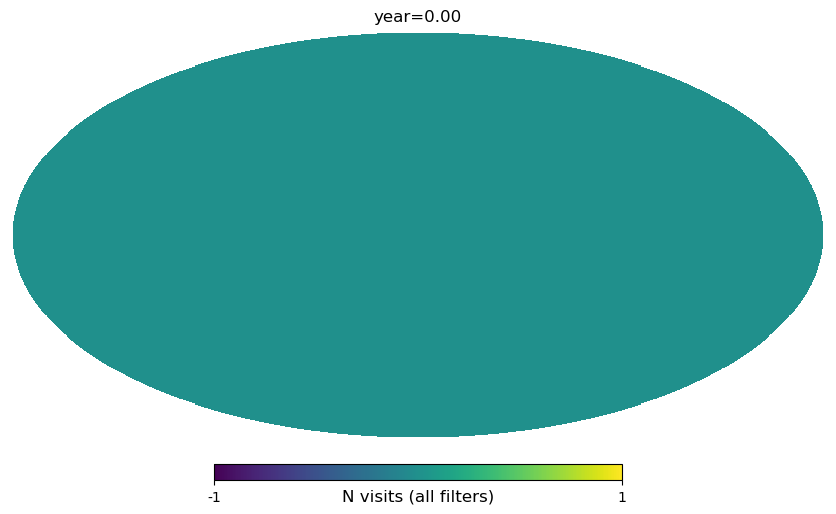

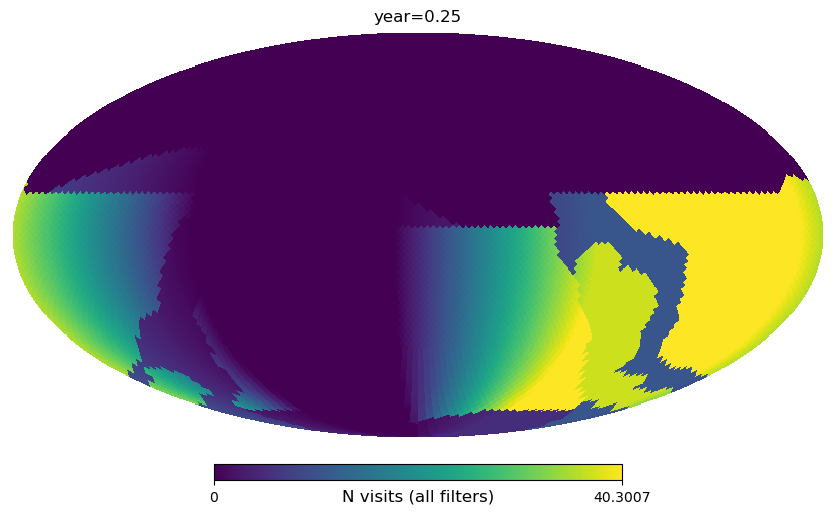

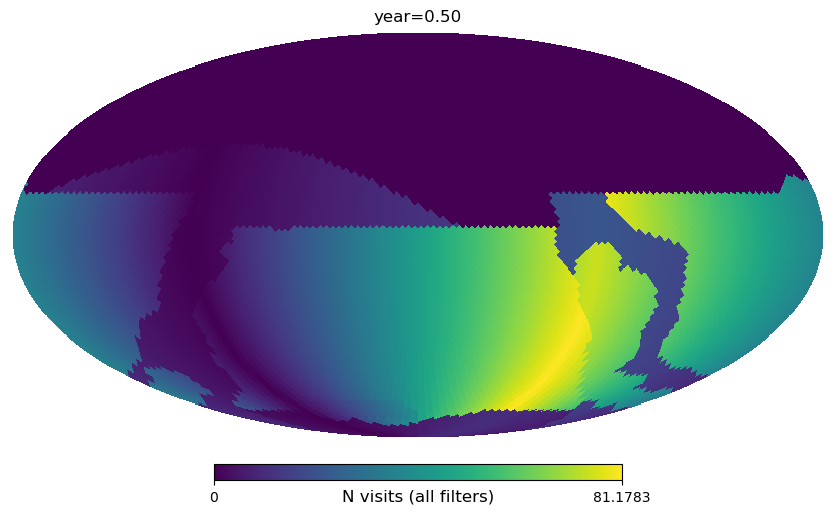

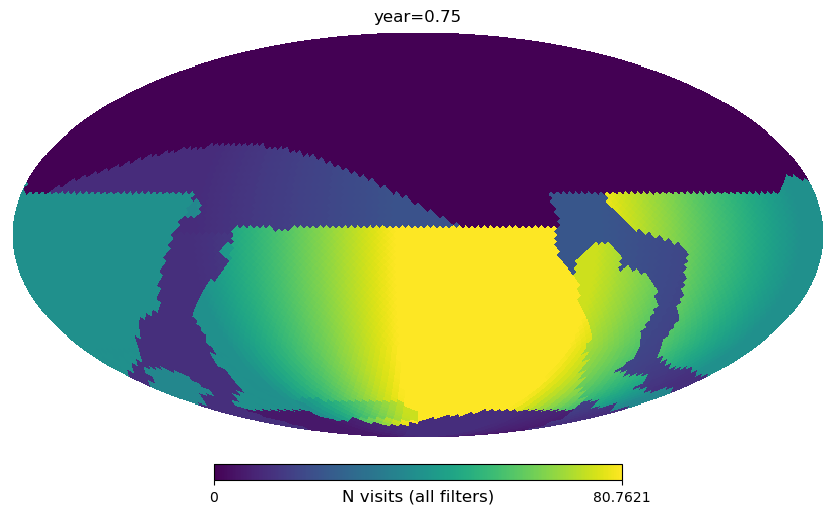

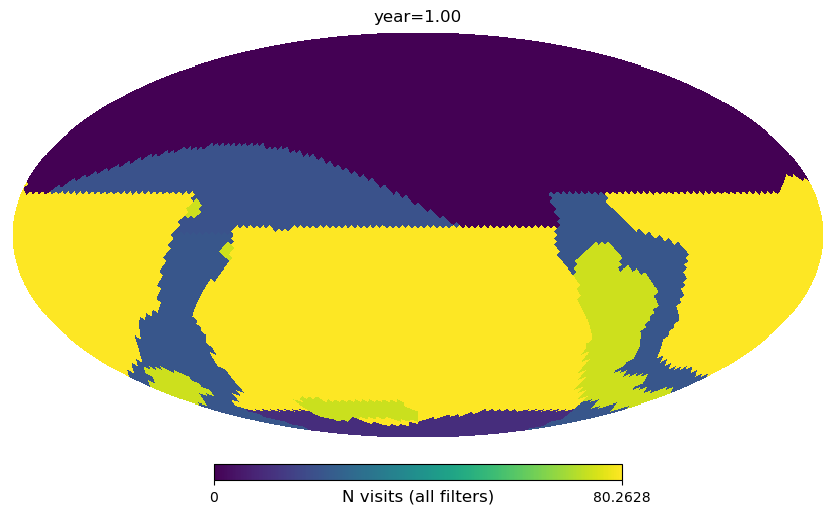

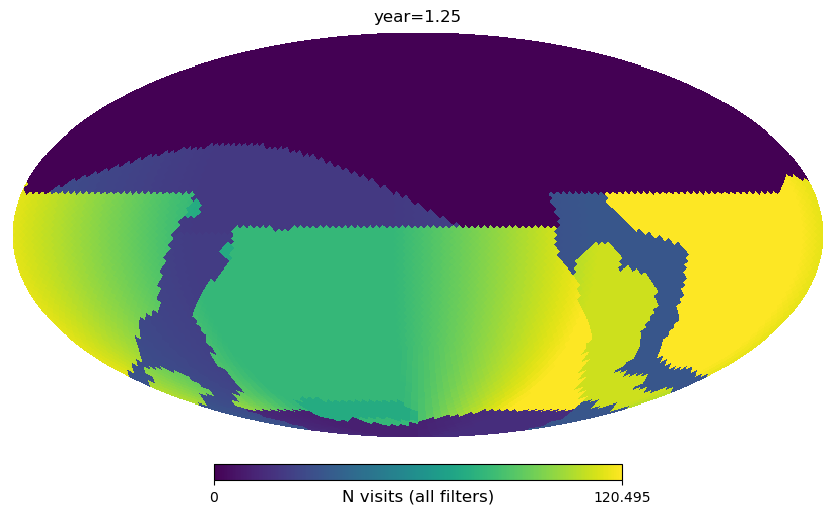

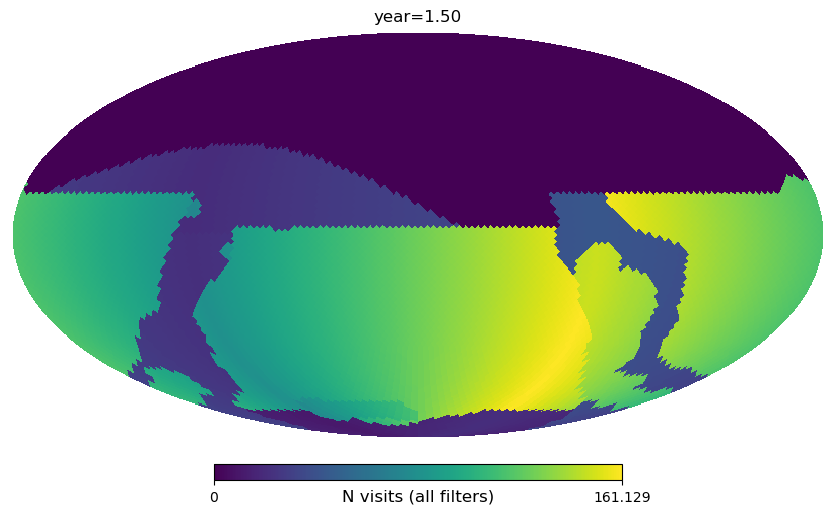

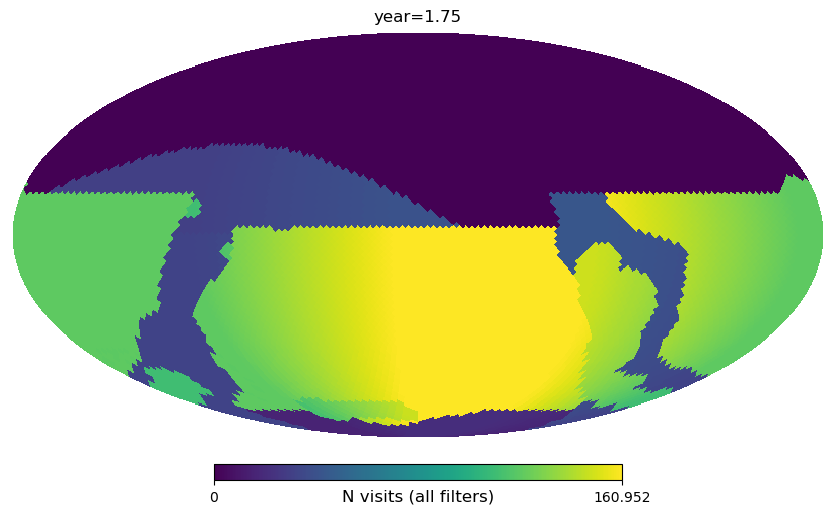

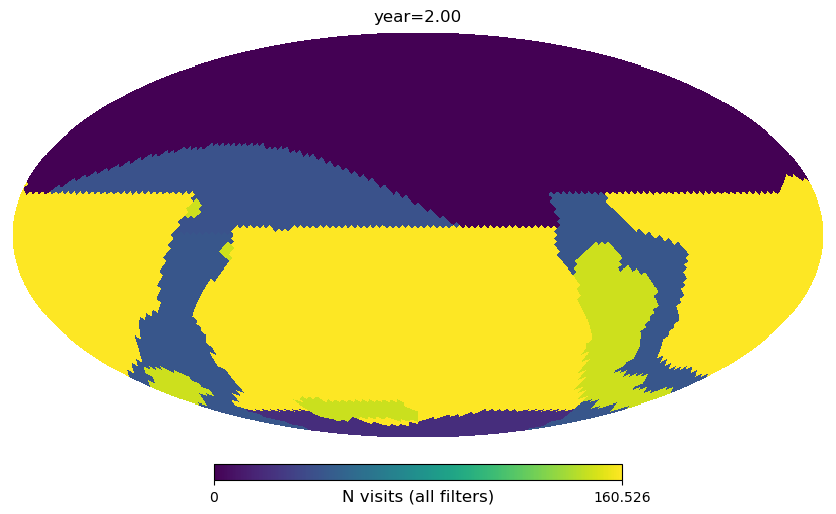

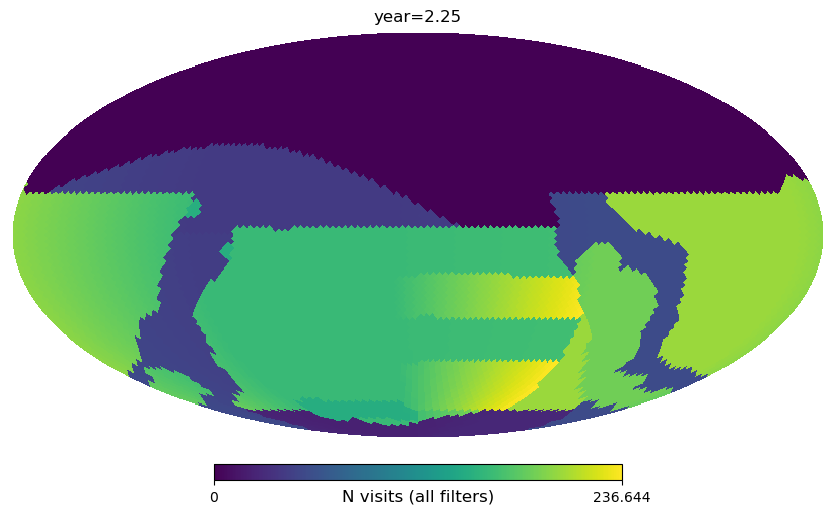

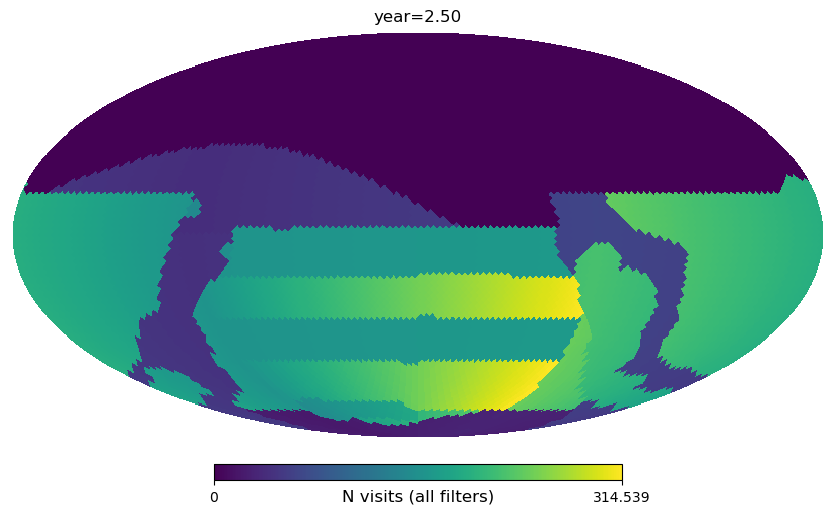

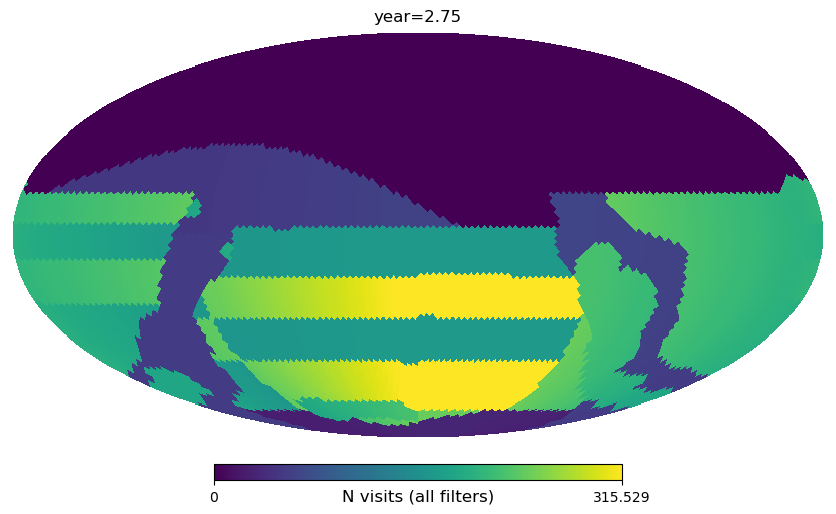

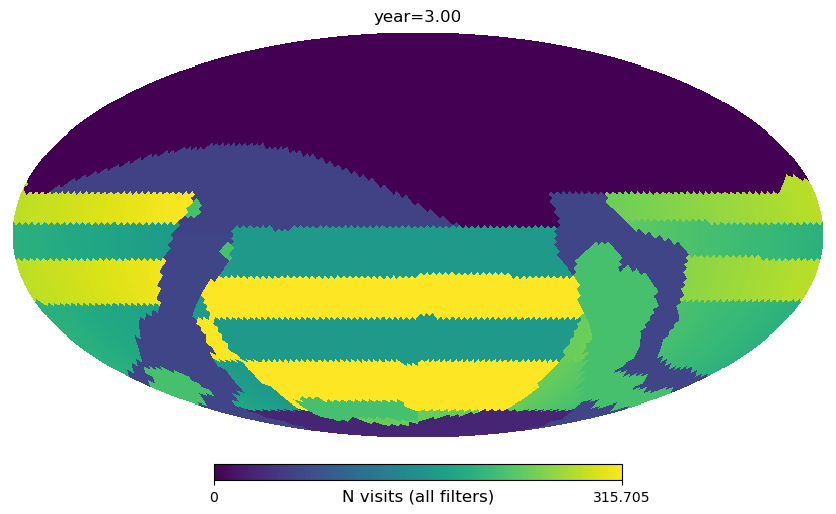

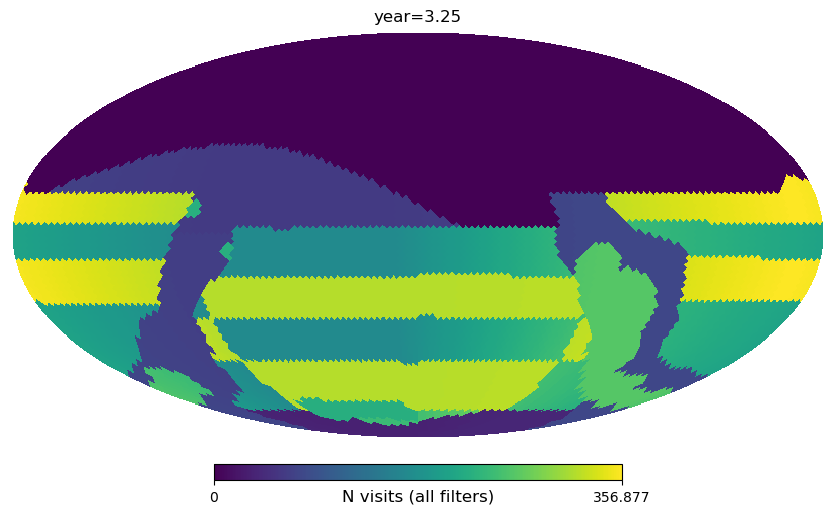

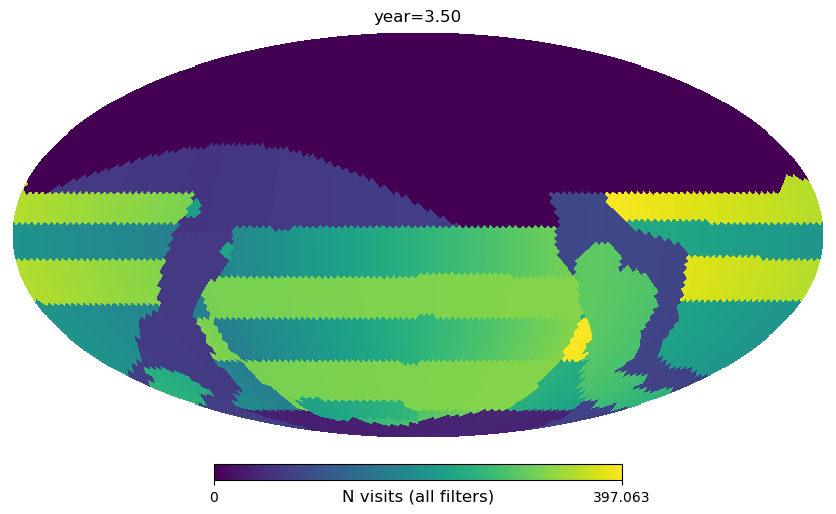

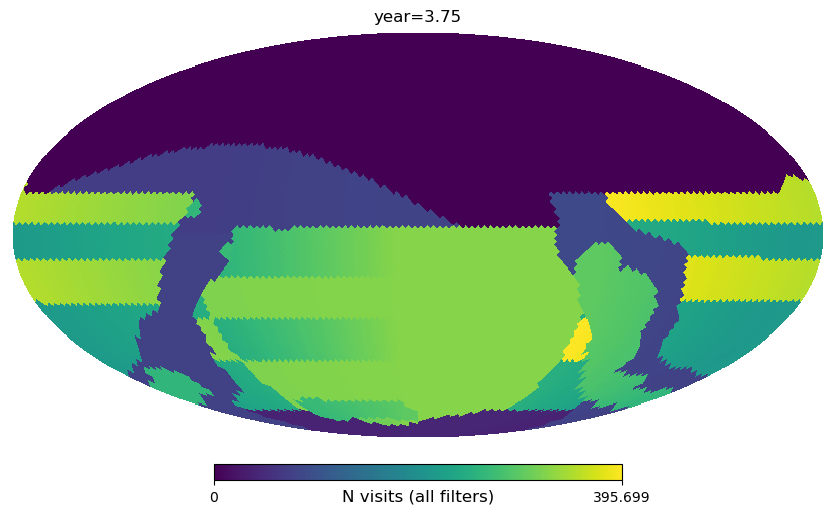

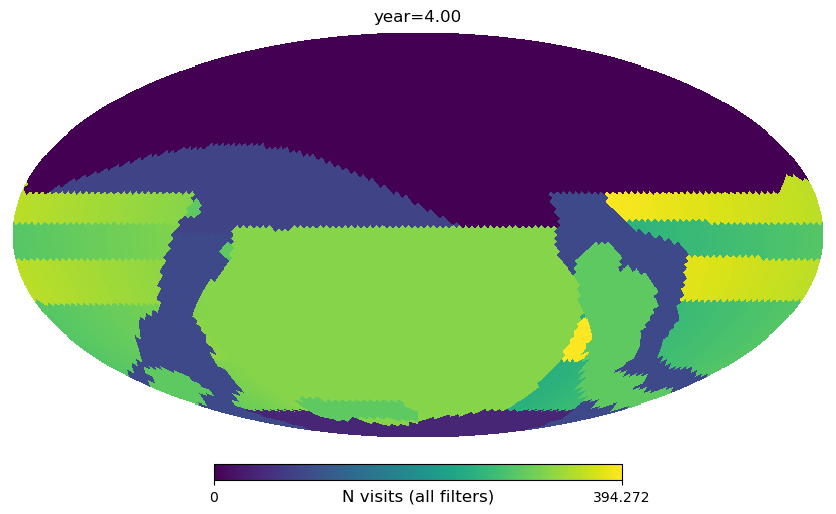

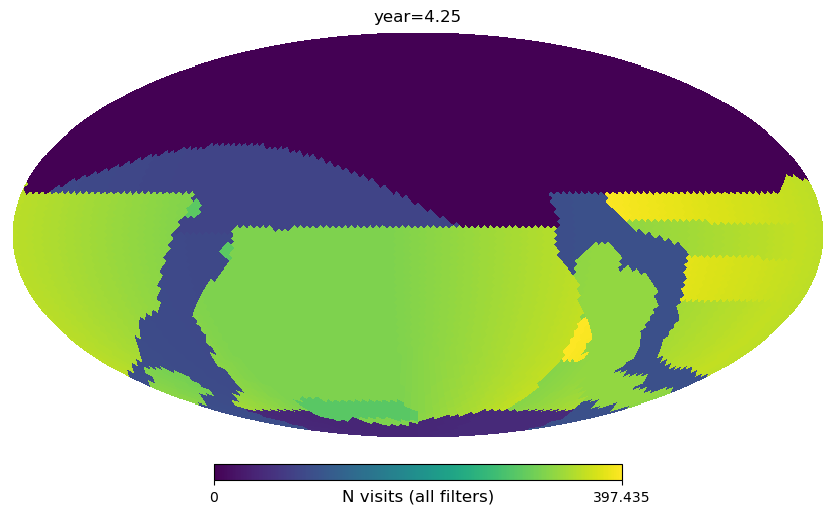

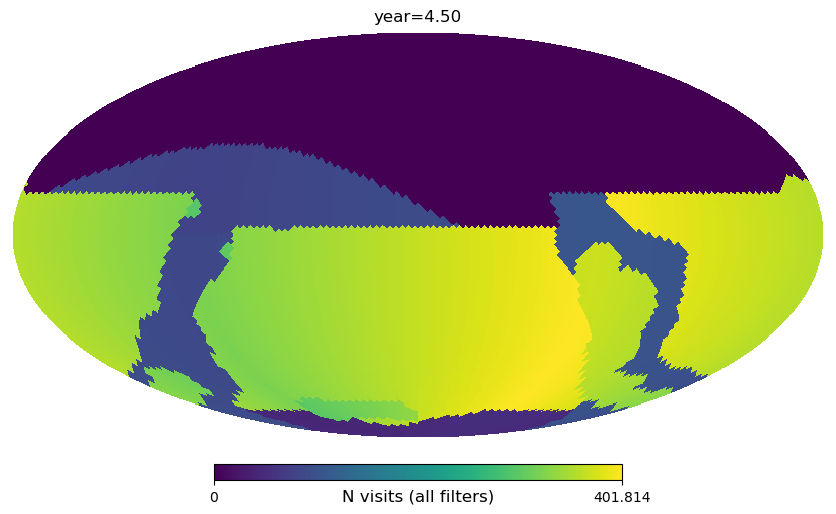

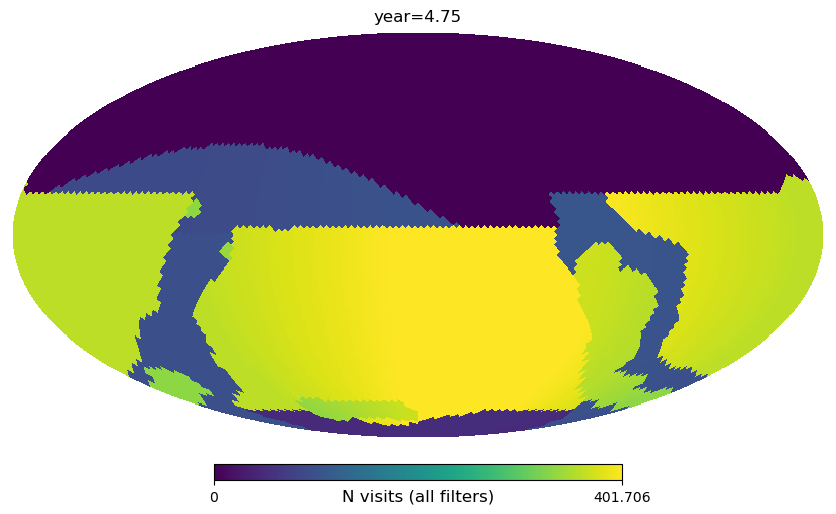

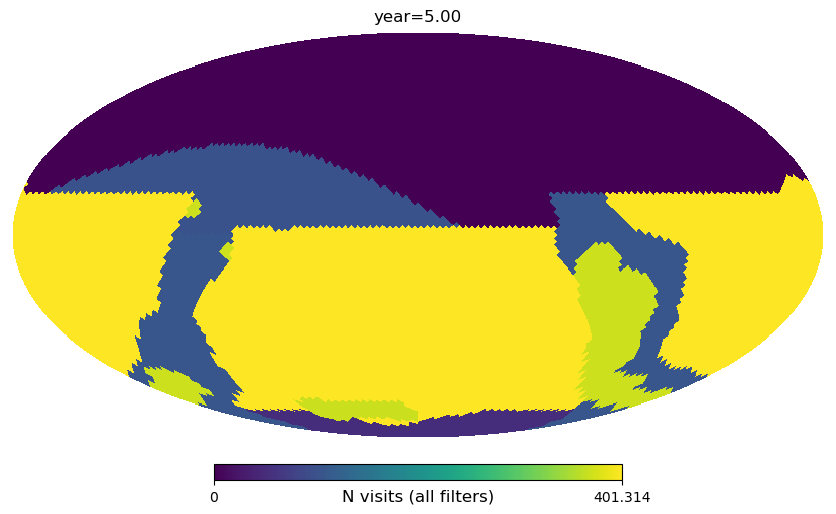

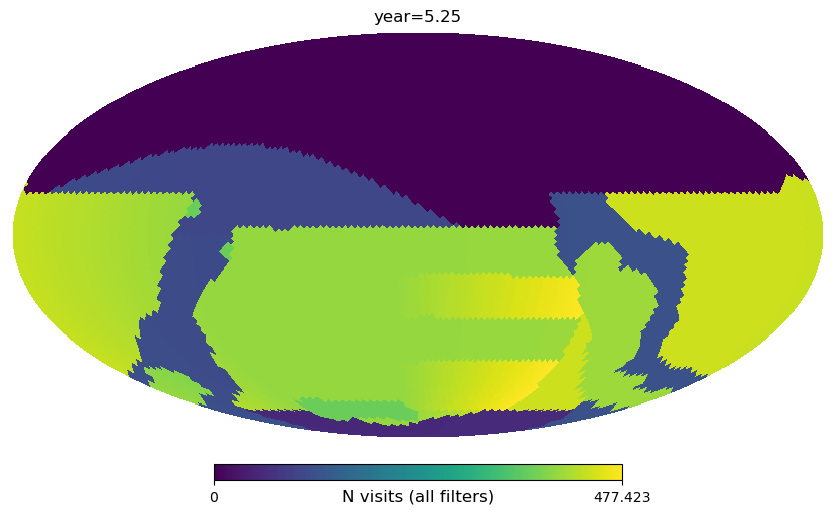

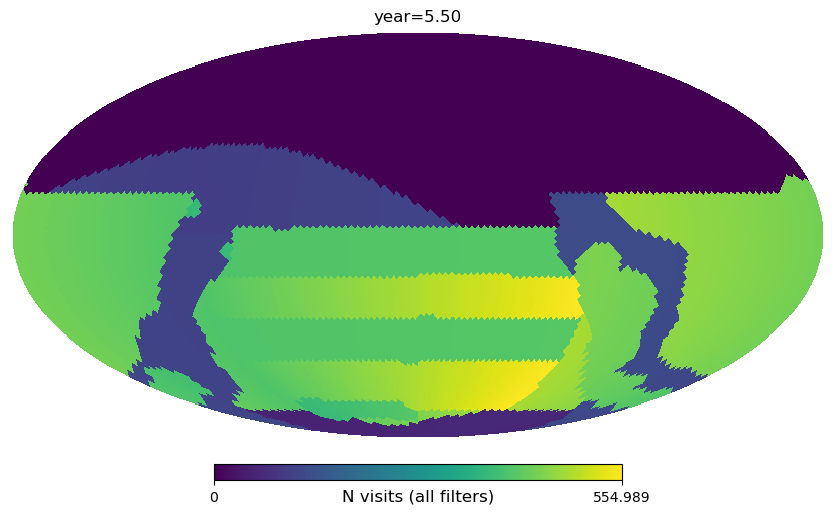

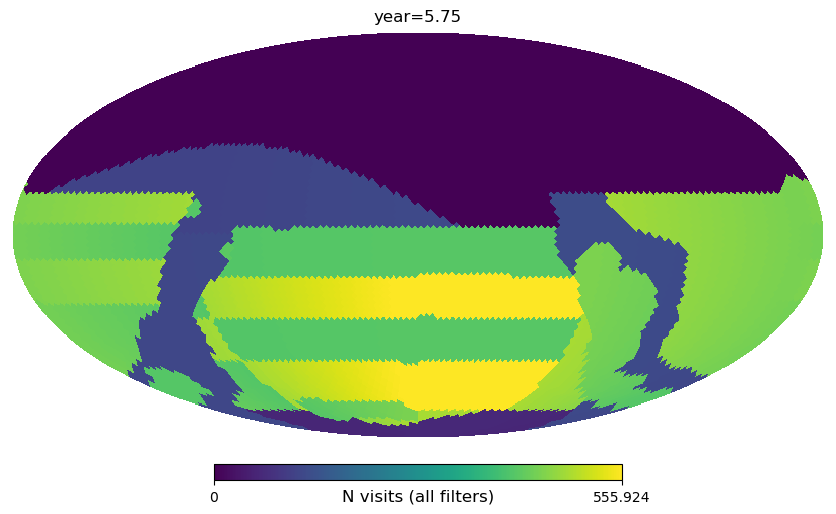

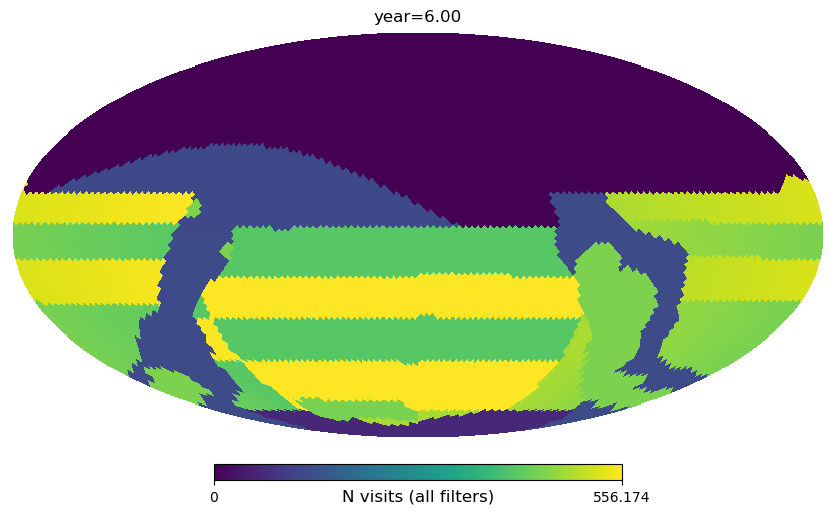

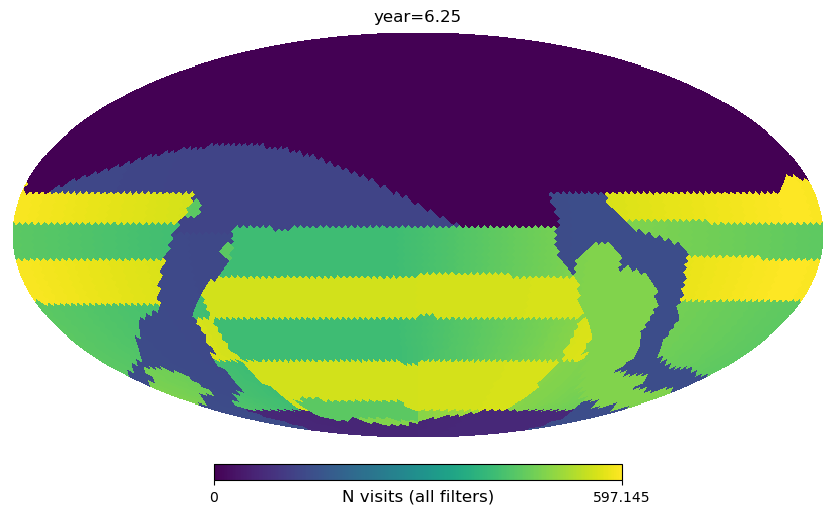

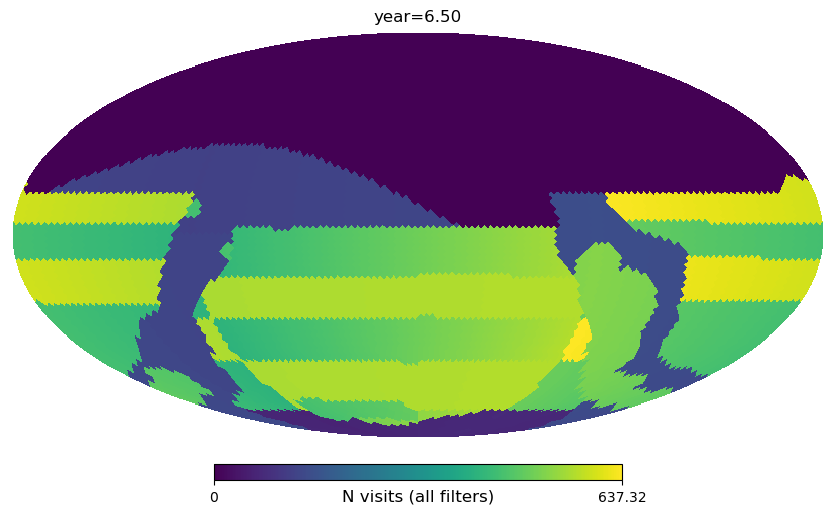

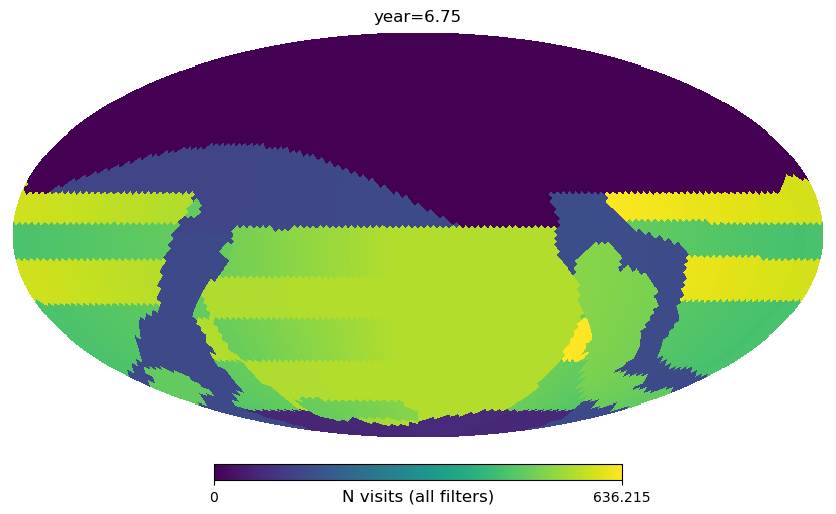

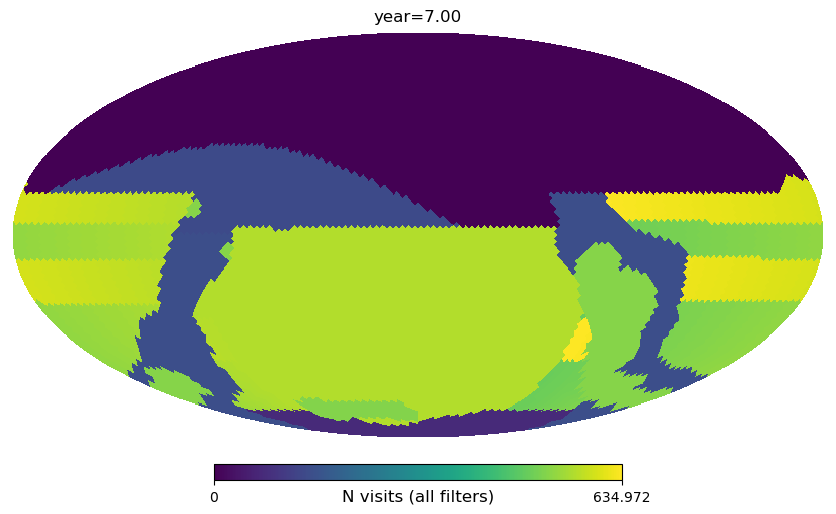

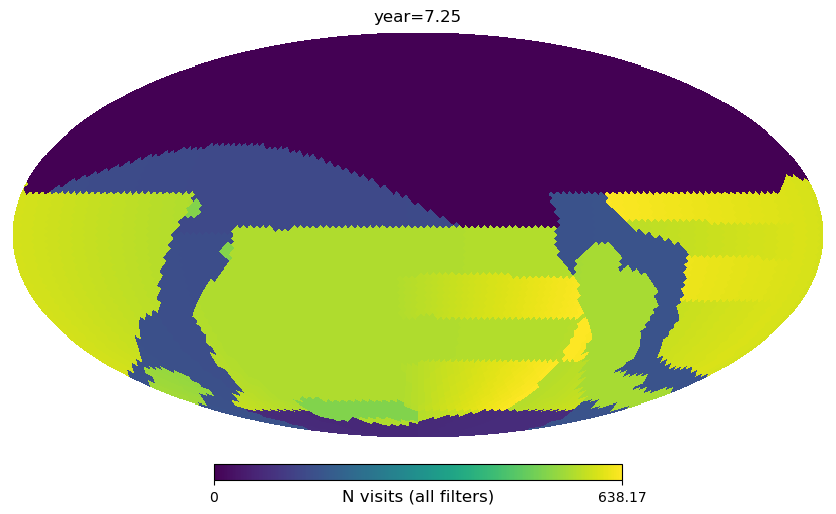

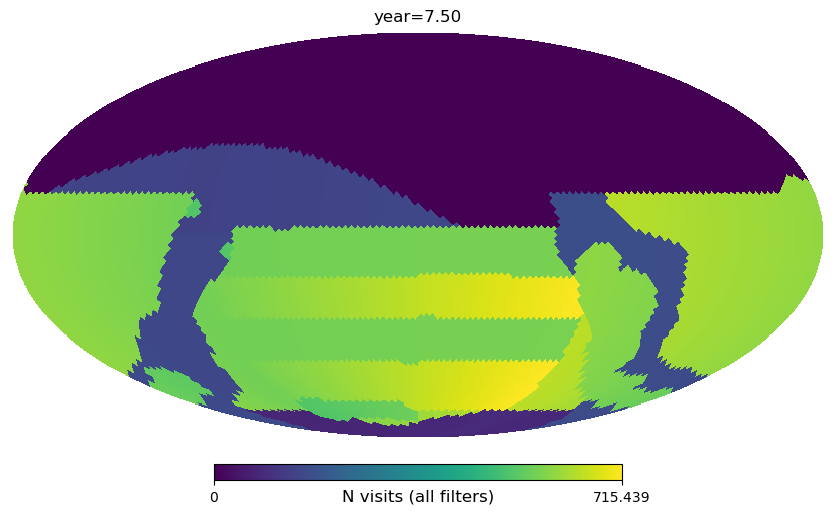

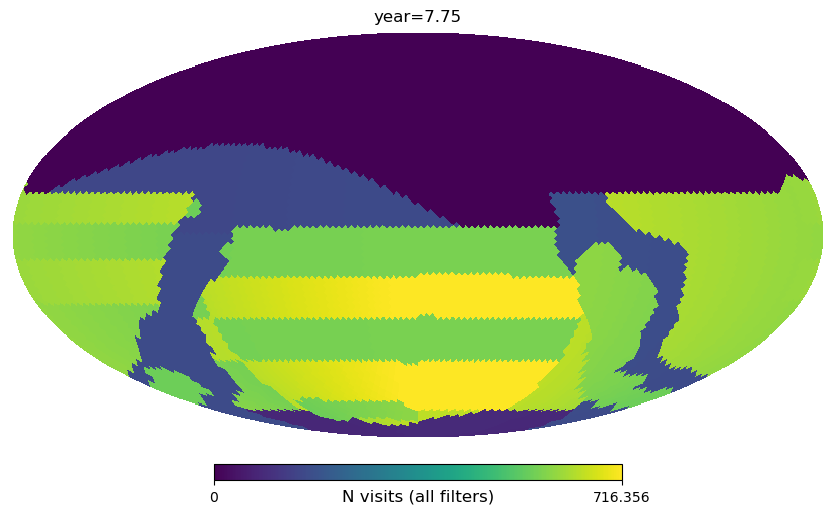

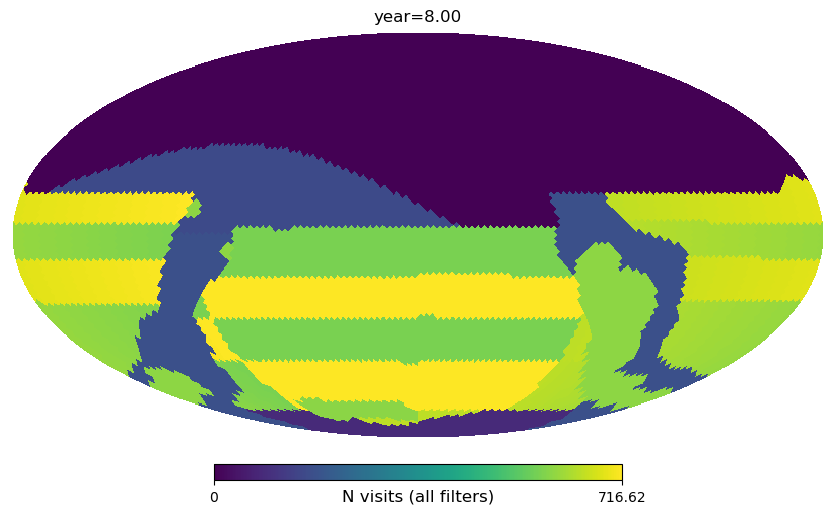

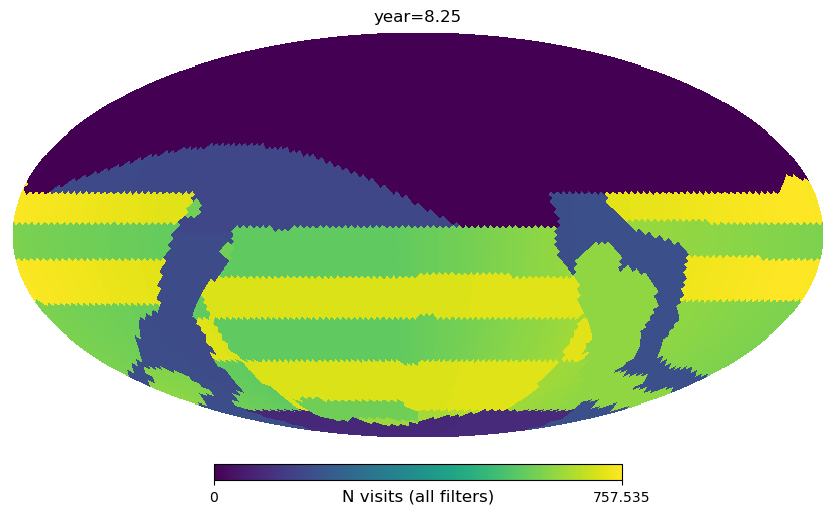

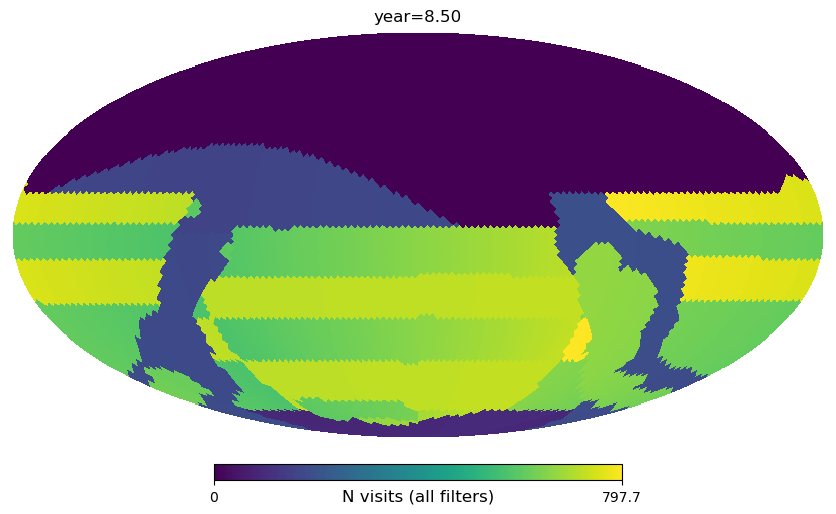

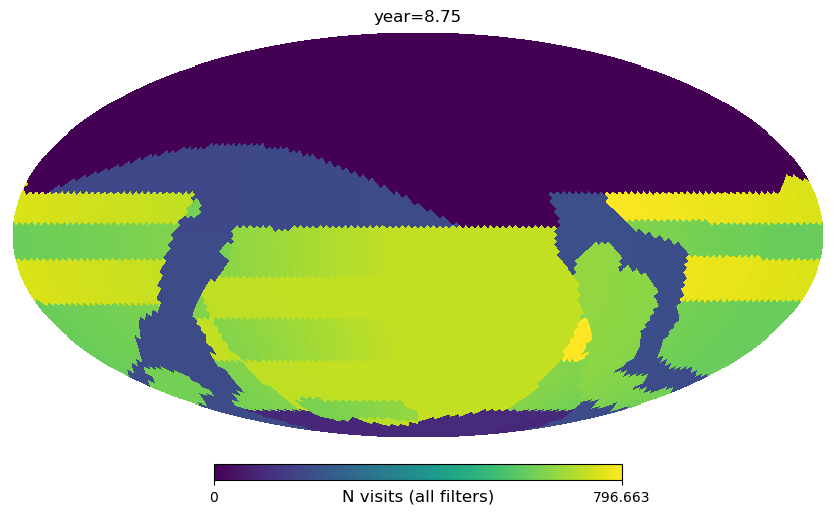

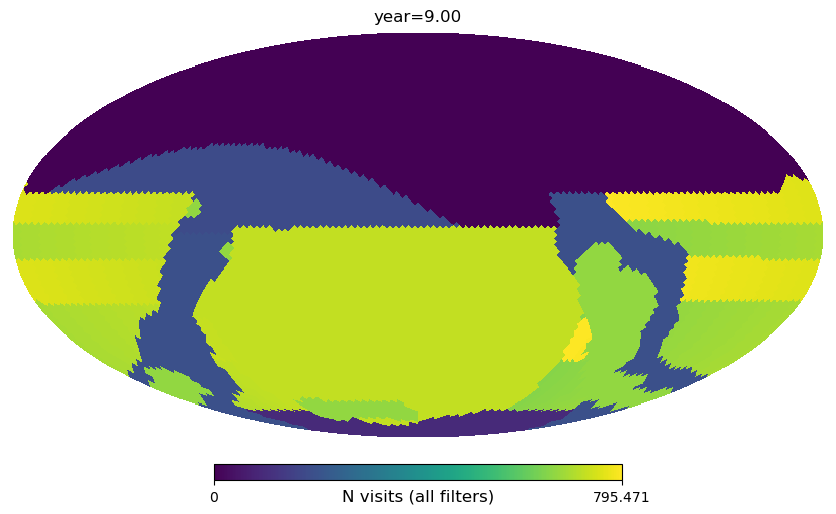

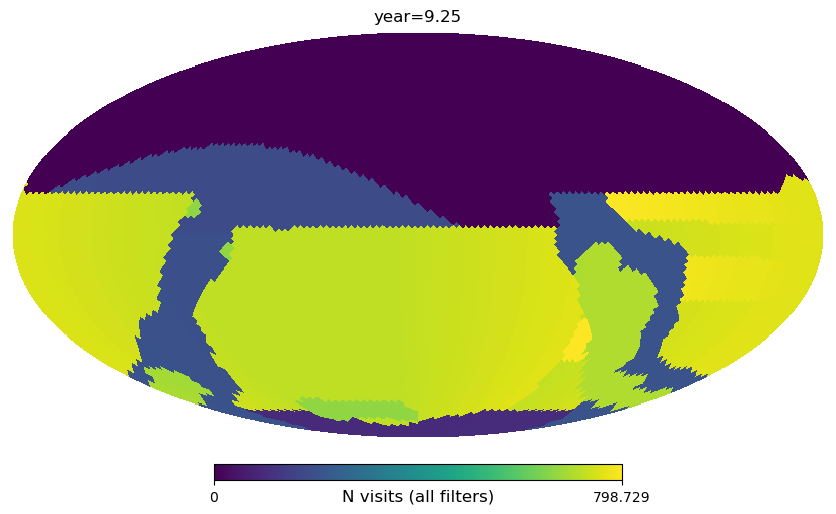

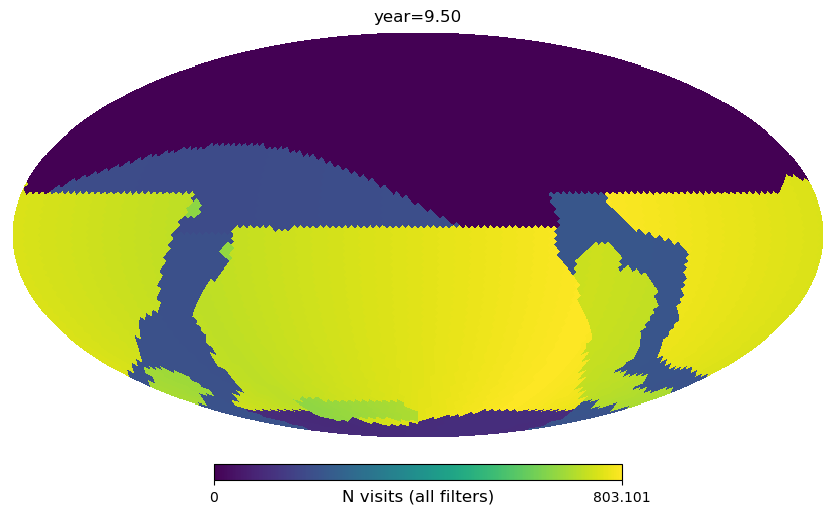

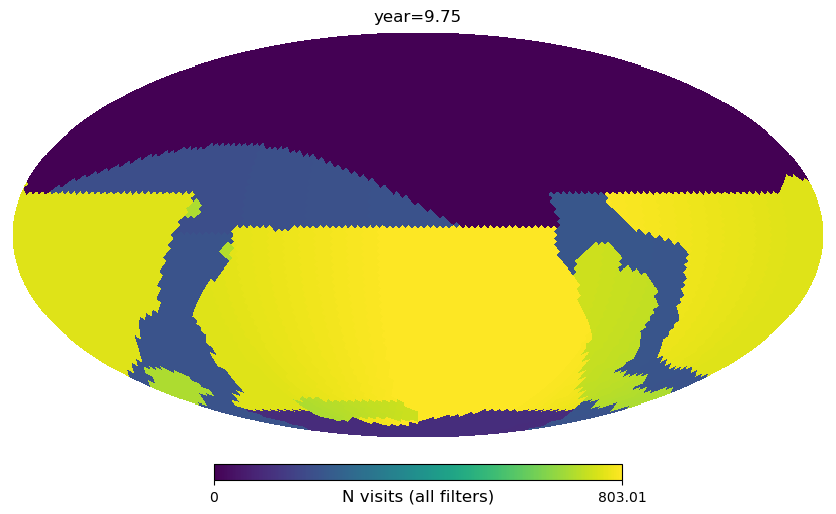

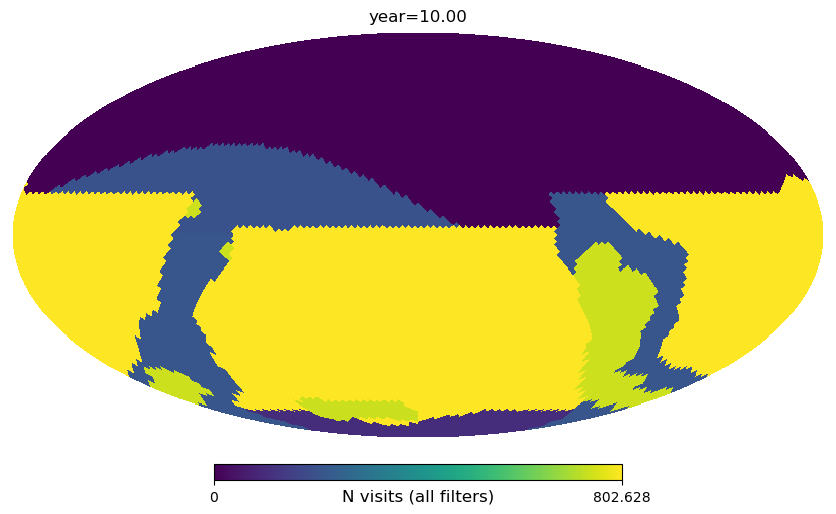

In [4]:
mjd = SURVEY_START_MJD + 10
step =  365.25/4
for mjd in SURVEY_START_MJD + np.arange(0,3652+step, step):
    # Assume we gather visits linearly. 
    fp_at_mjd = fp.estimate_counts(mjd, nvisits=1.8e6/3652*(mjd-SURVEY_START_MJD))
    sums = 0
    for key in fp_at_mjd.dtype.names:
        sums += fp_at_mjd[key]
    hp.mollview(sums, title='year=%.2f' % ((mjd-SURVEY_START_MJD)/365.25), unit="N visits (all filters)")
